# SAN Assignment - Generalized linear models

Author : Your Name

Email  : you@fel.cvut.cz

#### Introduction
The aim of this assignment is to practice constructing linear models. You will start with a simple linear model. You will evaluate and interpret it (1p). Consequently, your task will be to improve this model using generalized linear models (GLMs) and feature transformations. You will get 1p for proposal and evaluation of GLM (family, evaluation, interpretation), 1p for correct feature transformations, 2p for proposal and justification of the final model and eventually, 1p for comprehensive evaluation of all the model improvements (ablation study through cross-validation, note that the previous evaluations must be done without cross-validation).

Submit your solution consisting of both this modified notebook file and the exported PDF/HTML document as an archive to the courseware BRUTE upload system for the SAN course.
The deadline is specified there.

#### Input data 
In this assignment, you will work with a student dataset. The dataset contains 200 samples and 4 features: *num_awards* is the outcome variable and indicates the number of awards earned by students in a year, *math* is a continuous predictor variable and represents students’ scores on their math final exam, *prog* is a categorical predictor variable with three levels indicating the type of program in which the students were enrolled (1 = “General”, 2 = “Academic” and 3 = “Vocational”), and *work* is a continuous predictor that gives the number of hours that students spent at work on average per week.

#### Load the necessary libraries and the dataset

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import scipy.stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

print_precision = 3
cut_threshold = 1e5
thr = np.format_float_scientific(cut_threshold)
formatter_short = ("{:." + f"{print_precision}" + "f}").format
cond_formatter = lambda x: formatter_short(x) if np.abs(x) < cut_threshold else f">{thr}"

np.set_printoptions(formatter={'float_kind': cond_formatter})
pd.options.display.float_format = cond_formatter

In [3]:
df = pd.read_csv("study_data.csv")
X = df.loc[:, df.columns != "num_awards"]
X = sm.add_constant(X)
y = df.num_awards.to_numpy()

In [4]:
X.head()

,const,prog,math,work
45,1.000,3,41,19
108,1.000,1,41,31
15,1.000,3,44,3
67,1.000,3,42,34
153,1.000,3,40,0


In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 3, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 2, 0, 1, 0, 1, 0, 0, 2, 1, 3, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 3, 1, 0, 0, 0, 3, 0, 0, 1, 1, 0, 0, 0, 3, 0, 0, 0, 2,
       0, 1, 5, 0, 0, 1, 0, 0, 2, 4, 1, 0, 1, 1, 3, 1, 1, 3, 2, 0, 0, 1,
       1, 3, 2, 0, 6, 4, 1, 0, 2, 2, 1, 2, 1, 1, 0, 1, 2, 5, 1, 2, 2, 1,
       0, 3])

#### Simple linear model
Let us start with an ordinary linear model with no feature transformations. Explain how far the model works (does it meet formal assumptions?, does it overcome the null model?). Which predictors would you keep there and which of them are not useful? Use the standard evaluation procedures that we have for linear models (notice, that GML with Gaussian family corresponds to an OLS model, only the summary is slightly more general).


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     22.16
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.13e-12
Time:                        12:47:46   Log-Likelihood:                -264.40
No. Observations:                 200   AIC:                             536.8
Df Residuals:                     196   BIC:                             550.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5363      0.481     -5.268      0.0

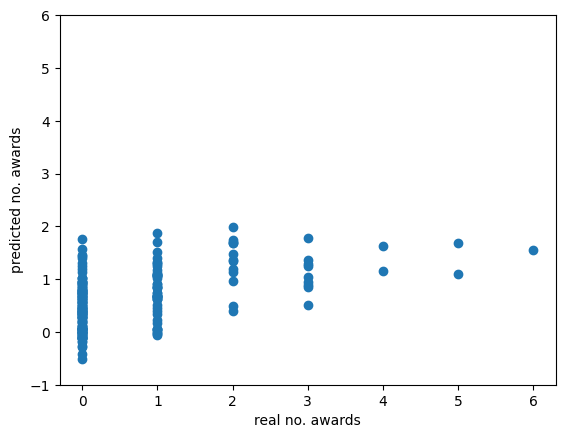

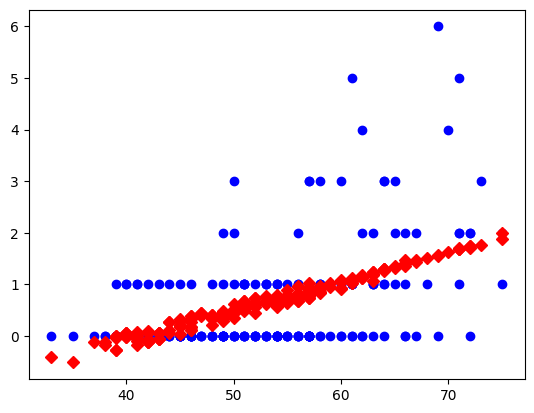

In [6]:
res = sm.OLS(endog=y, exog=X).fit()
print(res.summary())
print("")
print("-------------------------------------------------------------------------------")
print("")
res = sm.GLM(endog=y, exog=X, family=sm.families.Gaussian()).fit()
print(res.summary())

plt.scatter(y, res.predict(X))
plt.ylabel("predicted no. awards")
plt.xlabel("real no. awards")
plt.ylim((-1, 6))
plt.show()


try:
    sm.graphics.plot_fit(res, "math")
except AttributeError:
    pass
finally:
    plt.show()

In [ ]:
print("AIC score for OLS model: ", res.aic)

AIC score for OLR model:  536.7950226121017


In [47]:
null_model = sm.GLM(endog=y, exog=X.const, family=sm.families.Gaussian()).fit()
null_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      199
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                          1.1086
Method:                          IRLS   Log-Likelihood:                -293.60
Date:                Sun, 09 Nov 2025   Deviance:                       220.62
Time:                        18:30:09   Pearson chi2:                     221.
No. Iterations:                     3   Pseudo R-squ. (CS):          1.254e-05
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6300      0.074      8.462      0.000       0.484       0.776
==============================================================================
"""

In [48]:
print("AIC score for NULL model: ", null_model.aic)

AIC score for NULL model:  589.2002928805089


**Add your verbal summary and comments here (1p)**:

### **Model summary**
The ordinary linear regression model explains approximately 25% of the variance in the response variable (R² = 0.253, adjusted R² = 0.242). The overall F-statistic (22.16, p < 2.13e-12) indicates that at least one predictor significantly contributes to the model.

### **Individual p-tests checks**
Based on individual p-tests:
1. The variable prog has a p-value of 0.254 (> 0.05), and therefore this variable is not significant.
2. The variable math has a p-value of 0.000 (< 0.05), and therefore it is statistically significant.
3. The variable work has a p-value of 0.682 (> 0.05), which is not significant.

Therefore, from individual t-tests we can conclude that only math appears to be a useful predictor in this model and prog variable and work variable can be excluded.

#### **Assamption checks**
The dependent variable is a count, so the assumption of normally distributed residuals required by OLS does not hold. A Generalized Linear Model is therefore more appropriate.

#### **NULL model vs full ordinary linear regression model**
The model improves over the null model. The null model deviance 220.62 drops to 164.75 for the full model, and the log-likelihood increases from −293.60 to −264.40. This indicates that including predictors improves the model’s fit. The AIC is also lower, indicating a better overall fit for the full model.

### Generalized linear model
Now, the goal is to implement a generalized linear model that conceptually fits the given task. Do not transform the predictors yet, use them as they are, or omit them from the model. Once you obtain your model, interpret the effect of the *math* predictor on the outcome. How (according to your model) increasing a math score by one point affects the number of awards won? 

Explain why the model overcomes the previous linear model, or justify that the generalized model is not needed. Compare the models theoretically as well as technically in terms of a proper quality measure(s). Note: The difference between the models generally cannot be statistically tested.

Because in Python you cannot use *anova* function refer for example to the [Likelihood ration test (LTR)](https://www.statology.org/likelihood-ratio-test-in-python/) when comparing **nested** models, which you can easily implement yourself.

In [65]:
from scipy import stats

def compareGLM(model_simple, model_complex):
    LL_simple = model_simple.llf
    LL_complex = model_complex.llf
    df_diff = model_complex.df_model - model_simple.df_model
    LR_stat = 2 * (LL_complex - LL_simple)
    p_value = stats.chi2.sf(LR_stat, df_diff)

    print("=== GLM Model Comparison (Likelihood Ratio Test) ===")
    print(f"Log-likelihood (simple):   {LL_simple:.3f}")
    print(f"Log-likelihood (complex):  {LL_complex:.3f}")
    print(f"LR statistic:              {LR_stat:.3f}")
    print(f"Degrees of freedom diff:   {df_diff}")
    print(f"p-value:                   {p_value:.5f}")
    print(f"AIC (simple):              {model_simple.aic:.3f}")
    print(f"AIC (complex):             {model_complex.aic:.3f}")

In [ ]:
# TODO: add your code here
X_just_math = X.copy()
X_just_math = X_just_math.drop(columns=["prog", "work"])
X_just_math.head()

,const,math
45,1.000,41
108,1.000,41
15,1.000,44
67,1.000,42
153,1.000,40


In [77]:
glm_poiss_math = sm.GLM(y, X_just_math, family=sm.families.Poisson()).fit()
print(glm_poiss_math.summary())
print("AIC score for Poisson GLM model: ", glm_poiss_math.aic)
print(compareGLM(null_model, glm_poiss_math))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -190.04
Date:                Sun, 09 Nov 2025   Deviance:                       204.02
Time:                        19:50:01   Pearson chi2:                     229.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3418
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3335      0.591     -9.021      0.0

In [71]:
X_math_prog = X.copy()
X_math_prog = X_math_prog.drop(columns=["work"])
X_math_prog.head()

,const,prog,math
45,1.000,3,41
108,1.000,1,41
15,1.000,3,44
67,1.000,3,42
153,1.000,3,40


In [72]:
glm_poiss_math_prog = sm.GLM(y, X_math_prog, family=sm.families.Poisson()).fit()
print(glm_poiss_math_prog.summary())
print(compareGLM(glm_poiss_math, glm_poiss_math_prog))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      197
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -189.75
Date:                Sun, 09 Nov 2025   Deviance:                       203.45
Time:                        19:06:39   Pearson chi2:                     227.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3437
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.5781      0.677     -8.242      0.0

In [73]:
X_math_work = X.copy()
X_math_work = X_math_work.drop(columns=["prog"])
X_math_work.head()

,const,math,work
45,1.000,41,19
108,1.000,41,31
15,1.000,44,3
67,1.000,42,34
153,1.000,40,0


In [74]:
glm_poiss_math_work = sm.GLM(y, X_math_work, family=sm.families.Poisson()).fit()
print(glm_poiss_math_work.summary())
print(compareGLM(glm_poiss_math, glm_poiss_math_work))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      197
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -189.67
Date:                Sun, 09 Nov 2025   Deviance:                       203.29
Time:                        19:07:47   Pearson chi2:                     227.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3442
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.1722      0.620     -8.342      0.0

In [75]:
coef = glm_poiss_math.params['math']
irr = np.exp(coef)
pct = (irr - 1) * 100
print(f"math coef = {coef:.4f}, IRR = {irr:.3f}, => {pct:.2f}% change in expected awards per +1 math point")


math coef = 0.0862, IRR = 1.090, => 9.00% change in expected awards per +1 math point


**Add your verbal summary and comments here (1p)**:

#### Selecting best Poisson GLM model
From the previous analysis, only one predictor was statistically significant: math. Starting with the math-only Poisson model and comparing it to the null model, the math-only model significantly improves the fit (higher log-likelihood, lower AIC). Although individual tests suggested that the other two predictors (prog and work) are not significant, we nevertheless tested adding them. Both the likelihood ratio test (p-value > 0.05) and AIC showed no improvement, so the simpler model with only math is preferred.

#### Interpretation of the math effect
The estimated coefficient for math is 0.0862. In a Poisson GLM with log link the effect is multiplicative: the incidence rate ratio (IRR) is  exp(0.0862)=1.09. That means, an increase of one point in the math score corresponds to an expected increase of about 9% in the number of awards

#### Comparing Poisson GLM over OLS
The dependent variable (number of awards) represents counts, which violates the normality assumption required for OLS. The Poisson GLM is theoretically more appropriate because it models counts directly and ensures non-negative fitted values via the log link. Technically, the Poisson model also performs better on the available fit metrics: AIC decreased from 536.79 (OLS/Gaussian) to 384.07 (Poisson), and the log-likelihood increased from −264.40 (OLS) to −190.04 (Poisson). These indicate a better fit for the Poisson GLM.


### Feature transformations and final model
*prog* and *work* did not prove to be effective predictors so far. Visualize these predictors as well as their relationship with the outcome variable. Based on the observations, propose suitable transformations for them (or, justify that they are truly uninformative for prediction of *num_awards*) and implement them into the best model found by now. Use the *compareGLM()* function to validate that your new GLMs indeed improved over the simple one.

To achieve the same results as with R formulas (e.g. polynomial regression like *num_awards ~ poly(...)*) in Python you need to transform your features explicitly before passing them to your model. You do this by modifying the exog data in X.
For tools to do polynomial or spline transformations refer for example to sklearn:
[SplineTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html)
[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)




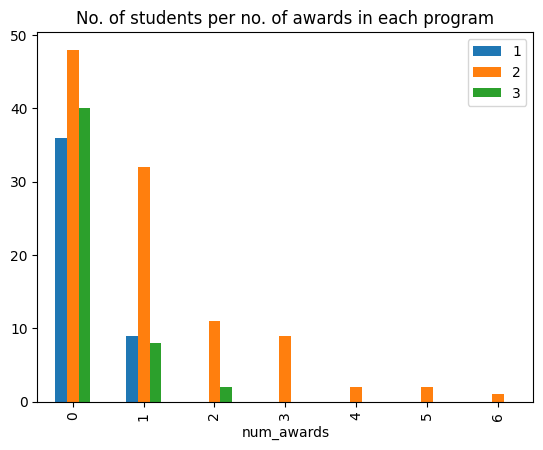

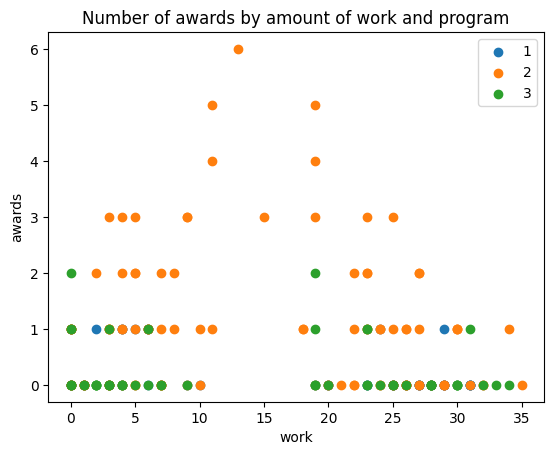

In [15]:
cols = ["num_awards", "prog"]
df_transformed = df[cols].groupby(cols).size().reset_index(level=-1)
programs = pd.unique(df_transformed.prog).tolist()
pd.concat([
    df_transformed.loc[df_transformed.prog == p, 0]
    for p in programs
], axis=1).set_axis(programs, axis="columns").plot.bar()
plt.title("No. of students per no. of awards in each program")
plt.show()

for p in programs:
    plt.scatter(df.work.loc[df.prog == p], df.num_awards.loc[df.prog == p], label=p)
plt.title("Number of awards by amount of work and program")
plt.xlabel("work")
plt.ylabel("awards")
plt.legend()
plt.show()

# TODO: add your code here


In [81]:
# Transforming prog variable to dummy variable
X_transformed_prog = X.copy()
X_transformed_prog = pd.get_dummies(X_transformed_prog, columns=["prog"], drop_first=True)
# Tranform dummy values to numeric
X_transformed_prog = X_transformed_prog.astype(float)
X_transformed_prog.head()

,const,math,work,prog_2,prog_3
45,1.000,41.000,19.000,0.000,1.000
108,1.000,41.000,31.000,0.000,0.000
15,1.000,44.000,3.000,0.000,1.000
67,1.000,42.000,34.000,0.000,1.000
153,1.000,40.000,0.000,0.000,1.000


In [85]:
X_transformed_no_work = X_transformed_prog.copy()
X_transformed_no_work = X_transformed_no_work.drop(columns=["work"])
X_transformed_no_work.head()

,const,math,prog_2,prog_3
45,1.000,41.000,0.000,1.000
108,1.000,41.000,0.000,0.000
15,1.000,44.000,0.000,1.000
67,1.000,42.000,0.000,1.000
153,1.000,40.000,0.000,1.000


In [86]:
glm_poiss_no_work = sm.GLM(y, X_transformed_no_work, family=sm.families.Poisson()).fit()
print(glm_poiss_no_work.summary())
print(compareGLM(glm_poiss_math_work, glm_poiss_no_work))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Sun, 09 Nov 2025   Deviance:                       189.45
Time:                        20:29:55   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.2471      0.658     -7.969      0.0

In [87]:
from sklearn.preprocessing import PolynomialFeatures

# Transform work variable as polynomial
X_transformed_full = X_transformed_prog.copy()
poly = PolynomialFeatures(degree=2, include_bias=False)
work_poly = poly.fit_transform(df[["work"]])
X_transformed_full["work"] = work_poly[:, 0]
X_transformed_full["work2"] = work_poly[:, 1]
X_transformed_full.head()

,const,math,work,prog_2,prog_3,work2
45,1.000,41.000,19.000,0.000,1.000,361.000
108,1.000,41.000,31.000,0.000,0.000,961.000
15,1.000,44.000,3.000,0.000,1.000,9.000
67,1.000,42.000,34.000,0.000,1.000,1156.000
153,1.000,40.000,0.000,0.000,1.000,0.000


In [88]:
glm_poiss_full_trans = sm.GLM(y, X_transformed_full, family=sm.families.Poisson()).fit()
print(glm_poiss_full_trans.summary())
print(compareGLM(glm_poiss_no_work, glm_poiss_full_trans))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      194
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -175.17
Date:                Sun, 09 Nov 2025   Deviance:                       174.29
Time:                        20:31:23   Pearson chi2:                     189.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4327
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.8927      0.681     -7.181      0.0

**Add your verbal summary and comments here (2p)** :


From the first graph (num of awards, program) we can see that predictor program has significant influence on num of awards, program 2 has more students with higher award counts.
So we will add prog variable to our model, but it is categorical variable so we transformed it to dummy variable.
So as first model we cunstruct poisson GLM model where we treated prog variable as dummy variable and removed work variable. We compared it with previously best model (only math model) and we got improvement of fit - lower AIC, higher log-likehood and also p-value is < 0.05.

From the second graph (number of awards by amount of work and program). It is look like work has nonlinear relationship to number of awards so we transformed it to polynomial.
So as second model we cunstruct poisson GLM model where we treated prog variable as dummy variable and work as polynomial variable. We compared it with previous model (math + prog as dummy variable) and again we got improvement of fit - lower AIC, higher log-likehood and also p-value is < 0.05.

### Ablation study through cross-validation
Recap all the models considered previously and evaluate them through cross-validation. You can start with the most simple null model and gradually add the previously discussed improvements. See their role in terms of MAE, RMSE and other commonly used criteria. The procedure outlined below proposes to work with the preprepared *train_with_cv* function, you can only add more models to evaluate and compare.

In [89]:
def test_glm_with_cv(X, y, model_type, model_name, model_family=sm.families.Gaussian(), n_folds=10):
    """
    You can use this function to test your GLM models in CV settings. If you want, you can edit
    this function, e.g. to have more comparison metrics, but justify it well in your commentary.

    :param X: your independent variables / features
    :param y: your response variable
    :param model_name: just for convenience you can name your models
    :param model_family: family of your GLM model (from statsmodels.families),
                        the default corresponds to an OLS model
    :param n_folds: number of folds to perform in your CV
    :return: returns a DataFrame with all the metrics for a particular model
    """
    assert model_type in ["lm", "glm"]
    data_metrics = {
        "MSE": lambda fit, x, y: mean_squared_error(y, x),
        "MAE": lambda fit, x, y: mean_absolute_error(y, x),
        "R2": lambda fit, x, y: r2_score(y, x),
        "LogLikelihood": lambda fit, x, y: fit.family.loglike_obs(endog=y, mu=x).sum(),
    }
    model_metrics = {
        "AIC": lambda fit: fit.aic,
        "BIC": lambda fit: fit.bic_llf,
    }
    
    skf = KFold(n_splits=n_folds, shuffle=True, random_state=0)
    metrics_results = defaultdict(list)
    for train_idxs, test_idxs in skf.split(X, y):
        model = sm.GLM(endog=y[train_idxs], exog=X[train_idxs], family=model_family)
        fit = model.fit()
        
        cmp = fit, y[test_idxs], fit.predict(X[test_idxs])
        for name, m in data_metrics.items():
            metrics_results[name].append(m(*cmp))

        for name, m in model_metrics.items():
            metrics_results[name].append(m(fit))

    res = pd.DataFrame({
        "Mean": [pd.Series(m).mean() for _, m in metrics_results.items()],
        "Sd": [pd.Series(m).std() for _, m in metrics_results.items()],
    }, index=[n for n, _ in metrics_results.items()])

    return res

In [90]:
# Here you have an example of the null lm model trained and tested with CV

# the sm.add_constant prepared a column "const" of ones for the intercept estimation
print("Mean Model Resuts")
print(test_glm_with_cv(
    X = X.const.to_numpy(),
    y = df.num_awards.to_numpy(),
    model_type = "lm",
    model_name="mean_model"
))

# TODO: add your code here
print("")
print("-------------------------------------------------------------------------------------")
print("Ordinary linear regression model resuts")
print(test_glm_with_cv(
    X = X.to_numpy(),
    y = df.num_awards.to_numpy(),
    model_type = "lm",
    model_name="ols_model"
))

print("")
print("-------------------------------------------------------------------------------------")
print("Generalized linear model with math feature and without transformations resuts")
print(test_glm_with_cv(
    X = X_just_math.to_numpy(),
    y = df.num_awards.to_numpy(),
    model_type = "glm",
    model_name="math_poiss_model",
    model_family=sm.families.Poisson()
))

print("")
print("-------------------------------------------------------------------------------------")
print("Generalized linear model with math and prog as dummy variable and without work resuts")
print(test_glm_with_cv(
    X = X_transformed_no_work.to_numpy(),
    y = df.num_awards.to_numpy(),
    model_type = "glm",
    model_name="poiss_model_2",
    model_family=sm.families.Poisson()
))

print("")
print("-------------------------------------------------------------------------------------")
print("Generalized linear model with math, prog as dummy variable and wih work as polynomial resuts")
print(test_glm_with_cv(
    X = X_transformed_full.to_numpy(),
    y = df.num_awards.to_numpy(),
    model_type = "glm",
    model_name="poiss_model_3",
    model_family=sm.families.Poisson()
))

Mean Model Resuts
                 Mean      Sd
MSE             1.115   0.639
MAE             0.785   0.142
R2            >1.e+05 >1.e+05
LogLikelihood -29.531   6.386
AIC           530.034  11.757
BIC           533.227  11.757

-------------------------------------------------------------------------------------
Ordinary linear regression model resuts
                 Mean     Sd
MSE             0.866  0.485
MAE             0.639  0.175
R2             -2.630  2.549
LogLikelihood -27.044  4.849
AIC           483.083 11.720
BIC           495.855 11.720

-------------------------------------------------------------------------------------
Generalized linear model with math feature and without transformations resuts
                 Mean    Sd
MSE             0.849 0.469
MAE             0.628 0.137
R2             -2.621 2.456
LogLikelihood >1.e+05   NaN
AIC           345.747 9.062
BIC           352.133 9.062

--------------------------------------------------------------------------------

c:\Users\gavul\Desktop\cvut_programming\CTU_SAN\venv\Lib\site-packages\statsmodels\genmod\families\family.py:477: RuntimeWarning: divide by zero encountered in log
  return var_weights / scale * (endog * np.log(mu) - mu -
c:\Users\gavul\Desktop\cvut_programming\CTU_SAN\venv\Lib\site-packages\statsmodels\genmod\families\family.py:477: RuntimeWarning: divide by zero encountered in log
  return var_weights / scale * (endog * np.log(mu) - mu -
c:\Users\gavul\Desktop\cvut_programming\CTU_SAN\venv\Lib\site-packages\statsmodels\genmod\families\family.py:477: RuntimeWarning: divide by zero encountered in log
  return var_weights / scale * (endog * np.log(mu) - mu -
c:\Users\gavul\Desktop\cvut_programming\CTU_SAN\venv\Lib\site-packages\statsmodels\genmod\families\family.py:477: RuntimeWarning: divide by zero encountered in log
  return var_weights / scale * (endog * np.log(mu) - mu -
c:\Users\gavul\Desktop\cvut_programming\CTU_SAN\venv\Lib\site-packages\statsmodels\genmod\families\family.py:477

**Add your verbal summary and comments here (1p)**:

Cross validation also approved our results from previous tasks: null model < full OLS < Poiss GLM only math < Poiss GLM only math + prog as dummy variable < Poiss GLM only math + prog as dummy variable + work as polynomial

## Feedback
Was some part of the notebook unclear, would any topic need more attention during the tutorials? 
If you want to leave us feedback on the assignment, we would be happy to hear it. 
Here is your space: